# RecruTap - Exploratory Data Analysis (EDA)

## Objective

This notebook performs an exploratory data analysis of the Fake Job Postings dataset used in the RecruTap project.

The objectives are:

- Understand the structure of the dataset
- Explore missing values and data quality
- Examine the distribution of fraudulent job postings
- Perform initial cleaning
- Export a cleaned dataset for feature engineering

## Dataset Overview

Dataset: Fake Job Postings

Source: Kaggle

Target Variable:
- fraudulent
    - 0 → Genuine Job Posting
    - 1 → Fraudulent Job Posting

## 1. Import Required Libraries

Import the libraries required for data manipulation and visualization.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Make plots look nicer
plt.style.use("ggplot")

## 2. Load Dataset

Load the raw CSV into a pandas DataFrame.

In [ ]:
df = pd.read_csv("../data/raw/fake_job_postings.csv")

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## 3. Initial Data Inspection

Display the first few records to understand the structure and available features.

In [16]:
df.head()

,job_id,title,location,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Other,Internship,Unknown,Unknown,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,Unknown,Unknown,Unknown,Unknown,Unknown,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## 4. Dataset Dimensions

Check the number of rows and columns.

In [18]:
print("Rows, Columns:", df.shape)

Rows, Columns: (17879, 16)


## 5. Dataset Information

Inspect column names, data types, and missing values.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17879 entries, 0 to 17879
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17879 non-null  int64 
 1   title                17879 non-null  object
 2   location             17879 non-null  object
 3   company_profile      17879 non-null  object
 4   description          17879 non-null  object
 5   requirements         17879 non-null  object
 6   benefits             17879 non-null  object
 7   telecommuting        17879 non-null  int64 
 8   has_company_logo     17879 non-null  int64 
 9   has_questions        17879 non-null  int64 
 10  employment_type      17879 non-null  object
 11  required_experience  17879 non-null  object
 12  required_education   17879 non-null  object
 13  industry             17879 non-null  object
 14  function             17879 non-null  object
 15  fraudulent           17879 non-null  int64 
dtypes: int64(

## 6. Statistical Summary

Generate descriptive statistics for both numerical and categorical variables.

In [4]:
df.describe(include="all")

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
count,17880.000000,17880,17534,6333,2868,14572,17879,15184,10668,17880.000000,17880.000000,17880.000000,14409,10830,9775,12977,11425,17880.000000
unique,NaN,11231,3105,1337,874,1709,14801,11967,6204,NaN,NaN,NaN,5,7,13,131,37,NaN
top,NaN,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,NaN,NaN,NaN,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,NaN
freq,NaN,311,718,551,142,726,379,410,726,NaN,NaN,NaN,11620,3809,5145,1734,1749,NaN
mean,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,0.795302,0.491723,NaN,NaN,NaN,NaN,NaN,0.048434
std,5161.655742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.202631,0.403492,0.499945,NaN,NaN,NaN,NaN,NaN,0.214688
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4470.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,13410.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000


## 7. Missing Value Analysis

Identify columns containing missing values and determine the extent of missing information.

In [6]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

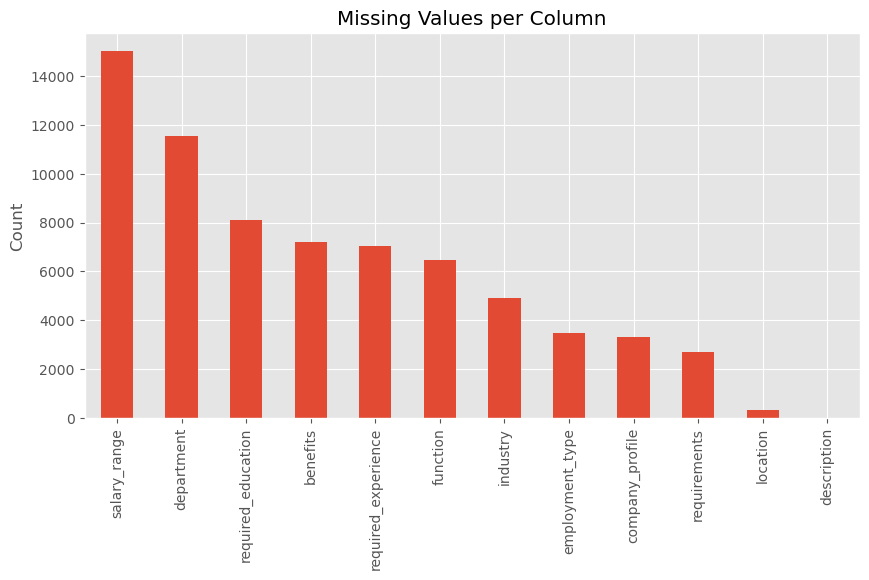

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.plot(kind="bar")

plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.show()

## 8. Duplicate Records

Check whether duplicate job postings exist.

In [17]:
df.duplicated().sum()

0

## 9. Data Cleaning

The following preprocessing steps are performed:

- Remove unnecessary columns
- Handle missing values
- Remove invalid records
- Prepare the dataset for feature engineering

In [8]:
# Drop columns with excessive missing values
df.drop(columns=["department", "salary_range"], inplace=True)

# Remove the single row with missing description
df.dropna(subset=["description"], inplace=True)

# Fill text columns
df["company_profile"] = df["company_profile"].fillna("")
df["requirements"] = df["requirements"].fillna("")
df["benefits"] = df["benefits"].fillna("")

# Fill categorical columns
df["location"] = df["location"].fillna("Unknown")
df["employment_type"] = df["employment_type"].fillna("Unknown")
df["required_experience"] = df["required_experience"].fillna("Unknown")
df["required_education"] = df["required_education"].fillna("Unknown")
df["industry"] = df["industry"].fillna("Unknown")
df["function"] = df["function"].fillna("Unknown")

## Verification

Confirm that the cleaned dataset no longer contains missing values.

In [9]:
df.isnull().sum()

job_id                 0
title                  0
location               0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

## 10. Target Variable Distribution

Examine the balance between genuine and fraudulent job postings.

In [11]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      865
Name: count, dtype: int64

In [12]:
df["fraudulent"].value_counts(normalize=True) * 100

fraudulent
0    95.161922
1     4.838078
Name: proportion, dtype: float64

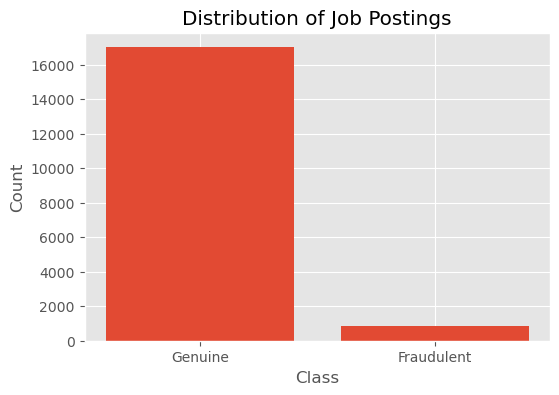

In [13]:
import matplotlib.pyplot as plt

counts = df["fraudulent"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Genuine","Fraudulent"], counts.values)
plt.title("Distribution of Job Postings")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Export Clean Dataset

Save the cleaned dataset for the next stage of the pipeline.

In [14]:
df.to_csv("../data/processed/clean_job_postings.csv", index=False)

# Conclusion

The exploratory analysis identified several data quality issues including missing values and incomplete categorical information.

After preprocessing:

- Missing values were handled
- Unnecessary information was removed
- The dataset was cleaned for downstream NLP processing

The cleaned dataset is now ready for Feature Engineering.